In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Problem Statement

In the competitive taxi industry, optimizing revenue streams is essential for long-term success and driver satisfaction. With the advent of digital payments, understanding how payment methods impact fare pricing has become increasingly important for maximizing earnings.

Our research focuses on leveraging **data-driven insights** to determine whether there is a significant relationship between the total fare amount and payment type. By analyzing the connection between payment methods (e.g., cash versus credit cards) and fare pricing, we aim to uncover actionable strategies for increasing driver revenue.

# Objective

The primary goal of this project is to conduct a hypothesis test to examine whether the method of payment influences total fare amounts. Using Python for hypothesis testing and descriptive statistics, we aim to answer the following:
- Are customers who pay via credit cards associated with higher fare amounts compared to those paying with cash?
- Can insights from payment trends guide strategies for encouraging higher-revenue payment methods without impacting customer satisfaction?

# Research Question

**Does the method of payment have a significant impact on the total fare amount?**

By answering this question, we aim to provide practical recommendations to taxi drivers and operators on how to align payment policies with revenue optimization.


## Importing Libraries

In [2]:
# to store and process data in dataframes
import pandas as pd
# basic visualization package
import matplotlib.pyplot as plt
# advanced ploting
import seaborn as sns
# for advanced statistics
import scipy.stats as stats
# for statistical plotting
import statsmodels.api as sm
# for regression analysis
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
# hide warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
# color pallette
edge, prim, sec, ter, quar, quin = '#000000', '#FA643F', '#FFBCAB', '#CBB2B2', '#F1F1F1', '#FD9F9F' 

# seaborn plot style
sns.set_style('darkgrid')

## Loading the Dataset

In [4]:
df = pd.read_csv('/kaggle/input/newyork-yellow-taxi-trip-data-2020-2019/yellow_tripdata_2020-01.csv')

In [5]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0


## Exploratory Data Analysis

In this section, we explore the dataset to understand its structure and key attributes. The main goals of EDA are:
1. Assess the completeness and cleanliness of the dataset.
2. Analyze distributions of important features such as `trip_distance`, `fare_amount`, and `pickup_datetime`.
3. Identify patterns or anomalies that might influence revenue.

In [6]:
# Understanding the size of data
df.shape

(6405008, 18)

In [7]:
# Ensuring the correct datatypes for each column
df.dtypes

VendorID                 float64
tpep_pickup_datetime      object
tpep_dropoff_datetime     object
passenger_count          float64
trip_distance            float64
RatecodeID               float64
store_and_fwd_flag        object
PULocationID               int64
DOLocationID               int64
payment_type             float64
fare_amount              float64
extra                    float64
mta_tax                  float64
tip_amount               float64
tolls_amount             float64
improvement_surcharge    float64
total_amount             float64
congestion_surcharge     float64
dtype: object

In [8]:
# Updating the dtype from object to datetime

df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])

In [9]:
# Verify the dtype change
df.dtypes

VendorID                        float64
tpep_pickup_datetime     datetime64[ns]
tpep_dropoff_datetime    datetime64[ns]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int64
DOLocationID                      int64
payment_type                    float64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
dtype: object

In [10]:
# Calculating duration of each trip

df['duration'] = df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']

In [11]:
# Reviewing the new column
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,duration
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5,0 days 00:04:48
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5,0 days 00:07:25
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5,0 days 00:06:11
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0,0 days 00:04:51
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0,0 days 00:02:18


In [12]:
# Updating the format of new column, so the duration is in minutes

df['duration'] = df['duration'].dt.total_seconds()/60

In [13]:
# Verify the format change

df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,duration
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5,4.800000
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5,7.416667
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5,6.183333
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0,4.850000
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0,2.300000


In [14]:
# Creating a focused subset based on our objective

subset_df = df[['passenger_count', 'payment_type', 'fare_amount', 'trip_distance', 'duration']]

In [15]:
subset_df.head()

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1.0,1.0,6.0,1.2,4.800000
1,1.0,1.0,7.0,1.2,7.416667
2,1.0,1.0,6.0,0.6,6.183333
3,1.0,1.0,5.5,0.8,4.850000
4,1.0,2.0,3.5,0.0,2.300000


In [16]:
# Checking for missing values

subset_df.isnull().sum()

passenger_count    65441
payment_type       65441
fare_amount            0
trip_distance          0
duration               0
dtype: int64

In [17]:
# Getting percent of missing data

print((subset_df['passenger_count'].isnull().sum() / subset_df.shape[0]) * 100)
print((subset_df['payment_type'].isnull().sum() / subset_df.shape[0]) * 100)

1.021716132126611
1.021716132126611


In [18]:
# Since the percent of missing data is very low it won't affect our analysis and hence can be safely dropped

subset_df.dropna(axis = 0, inplace = True)

In [19]:
# Confirming that there is no leftover missing value

subset_df.isnull().sum()

passenger_count    0
payment_type       0
fare_amount        0
trip_distance      0
duration           0
dtype: int64

In [20]:
# Converting dtypes for a few columns

subset_df['passenger_count'] = subset_df['passenger_count'].astype('int64')
subset_df['payment_type'] = subset_df['payment_type'].astype('int64')

In [21]:
subset_df.head()

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1,1,6.0,1.2,4.800000
1,1,1,7.0,1.2,7.416667
2,1,1,6.0,0.6,6.183333
3,1,1,5.5,0.8,4.850000
4,1,2,3.5,0.0,2.300000


In [22]:
subset_df[subset_df.duplicated()]

,passenger_count,payment_type,fare_amount,trip_distance,duration
2056,1,2,7.0,0.00,0.000000
2441,1,1,52.0,0.00,0.200000
2446,2,1,9.5,1.70,13.066667
2465,1,1,4.0,0.40,3.083333
3344,1,1,6.0,1.20,5.350000
...,...,...,...,...,...
6339558,1,2,8.0,1.63,8.800000
6339559,1,1,8.5,1.81,8.016667
6339560,1,2,6.5,0.98,6.900000
6339562,1,1,11.0,2.10,14.233333


In [23]:
# We see high duplicate count as we have ignored quite a few columns from original dataset. 
# These duplicate rows will not contibute anything to our analysis hence can be safely dropped.

subset_df.drop_duplicates(inplace = True)

In [24]:
subset_df[subset_df.duplicated()]

,passenger_count,payment_type,fare_amount,trip_distance,duration


In [25]:
subset_df.shape

(3007861, 5)

In [26]:
# Understanding the range and percent of each possible value for different columns

subset_df['passenger_count'].value_counts(normalize = True)

passenger_count
1    0.581981
2    0.190350
3    0.066360
5    0.062937
6    0.039272
4    0.036046
0    0.023033
7    0.000009
9    0.000006
8    0.000006
Name: proportion, dtype: float64

In [27]:
subset_df['payment_type'].value_counts(normalize = True)

payment_type
1    6.782670e-01
2    3.075731e-01
3    8.721480e-03
4    5.438084e-03
5    3.324622e-07
Name: proportion, dtype: float64

In [28]:
# Based on column description of our data we only want to consider Credit card and cash payments

subset_df = subset_df[subset_df['payment_type']<3]

# Since no passenger situation is not possible and count of passengers more than 6 contirbutes very less in our data we can safely ignore those records.
subset_df = subset_df[(subset_df['passenger_count']>0) & (subset_df['passenger_count']<6)]

In [29]:
subset_df['passenger_count'].value_counts(normalize = True)

passenger_count
1    0.618771
2    0.203503
3    0.071196
5    0.067902
4    0.038628
Name: proportion, dtype: float64

In [30]:
subset_df['payment_type'].value_counts(normalize = True)

payment_type
1    0.686189
2    0.313811
Name: proportion, dtype: float64

In [31]:
subset_df.shape

(2780283, 5)

In [32]:
subset_df['payment_type'].replace([1,2], ['Card', 'Cash'], inplace = True)

In [33]:
subset_df.head()

,passenger_count,payment_type,fare_amount,trip_distance,duration
0,1,Card,6.0,1.2,4.800000
1,1,Card,7.0,1.2,7.416667
2,1,Card,6.0,0.6,6.183333
3,1,Card,5.5,0.8,4.850000
4,1,Cash,3.5,0.0,2.300000


In [34]:
subset_df.describe()

,passenger_count,fare_amount,trip_distance,duration
count,2.780283e+06,2.780283e+06,2.780283e+06,2.780283e+06
mean,1.733386e+00,1.780567e+01,4.536729e+00,2.415478e+01
std,1.176652e+00,1.506997e+01,4.895890e+00,9.260031e+01
min,1.000000e+00,-5.000000e+02,-2.218000e+01,-2.770367e+03
25%,1.000000e+00,9.000000e+00,1.500000e+00,9.883333e+00
50%,1.000000e+00,1.300000e+01,2.730000e+00,1.573333e+01
75%,2.000000e+00,2.100000e+01,5.470000e+00,2.336667e+01
max,5.000000e+00,4.265000e+03,2.628800e+02,8.525117e+03


In [35]:
# We can see some incorrect data as negative values for fare_amount, trip_distance or duration are not possible, hence need to be removed

subset_df = subset_df[subset_df['fare_amount'] > 0]
subset_df = subset_df[subset_df['trip_distance'] > 0]
subset_df = subset_df[subset_df['duration'] > 0]

In [36]:
subset_df.describe()

,passenger_count,fare_amount,trip_distance,duration
count,2.748932e+06,2.748932e+06,2.748932e+06,2.748932e+06
mean,1.738151e+00,1.766835e+01,4.583313e+00,2.418261e+01
std,1.179440e+00,1.447531e+01,4.897806e+00,9.272285e+01
min,1.000000e+00,1.000000e-02,1.000000e-02,1.666667e-02
25%,1.000000e+00,9.000000e+00,1.530000e+00,9.950000e+00
50%,1.000000e+00,1.300000e+01,2.770000e+00,1.575000e+01
75%,2.000000e+00,2.100000e+01,5.500000e+00,2.333333e+01
max,5.000000e+00,4.265000e+03,2.628800e+02,8.525117e+03


{'whiskers': [<matplotlib.lines.Line2D at 0x78f764de1cf0>,
 'caps': [<matplotlib.lines.Line2D at 0x78f764de2230>,
 'boxes': [<matplotlib.lines.Line2D at 0x78f764de1a50>],
 'medians': [<matplotlib.lines.Line2D at 0x78f764de2770>],
 'fliers': [<matplotlib.lines.Line2D at 0x78f764de2a10>],
 'means': []}

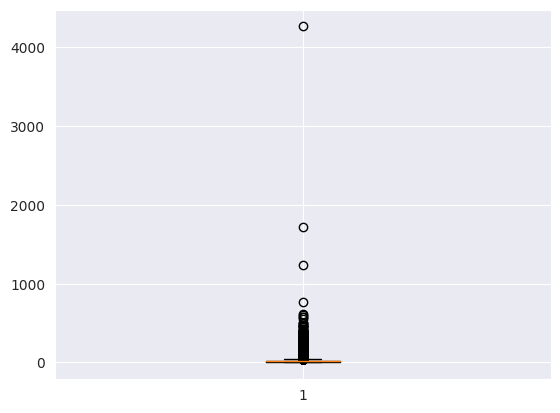

In [37]:
# Checking for outliers

plt.boxplot(subset_df['fare_amount'])

In [38]:
# Outliers can be handled either using Z score or IQR. But since the data is not normally distributed we will be using IQR

for col in ['fare_amount', 'trip_distance', 'duration']:
    q1 = subset_df[col].quantile(0.25)
    q3 = subset_df[col].quantile(0.75)
    IQR = q3 - q1

    lower_bound = q1 - 1.5*IQR
    upper_bound = q3 + 1.5*IQR

    subset_df = subset_df[(subset_df[col] >= lower_bound) & (subset_df[col] <= upper_bound)]

{'whiskers': [<matplotlib.lines.Line2D at 0x78f764ca25f0>,
 'caps': [<matplotlib.lines.Line2D at 0x78f764e7faf0>,
 'boxes': [<matplotlib.lines.Line2D at 0x78f764ca2350>],
 'medians': [<matplotlib.lines.Line2D at 0x78f764ca2d10>],
 'fliers': [<matplotlib.lines.Line2D at 0x78f764ca2fb0>],
 'means': []}

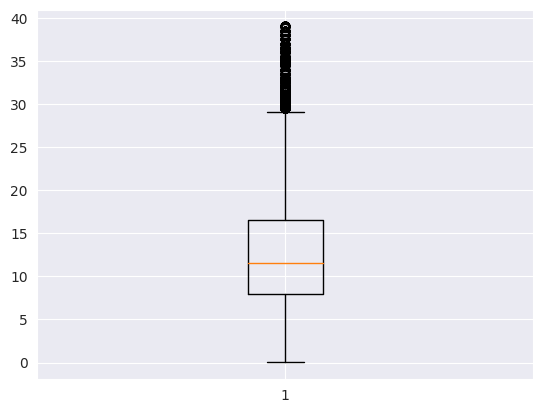

In [39]:
plt.boxplot(subset_df['fare_amount'])

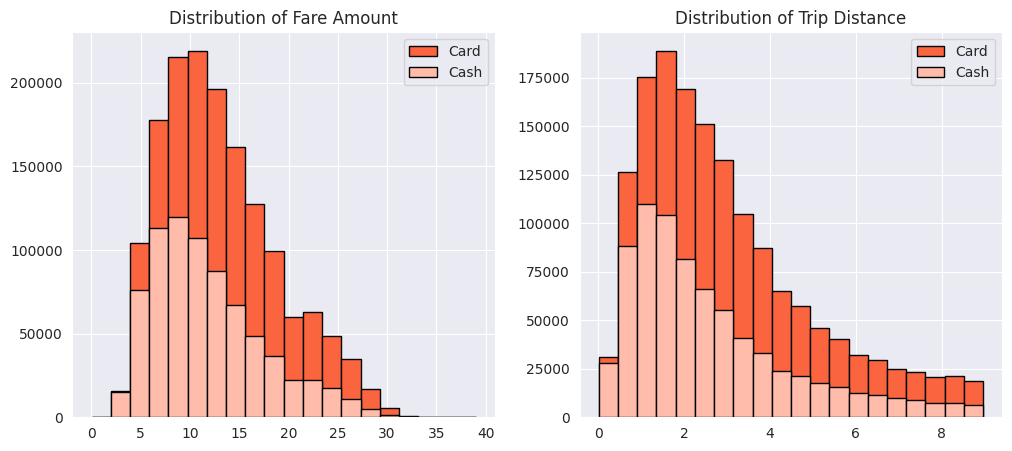

In [40]:
# Visualizing choice of payment type based on fare amount & trip distance

plt.figure(figsize = (12,5))
plt.subplot(1,2,1)
plt.title('Distribution of Fare Amount')
plt.hist(subset_df[subset_df['payment_type'] == 'Card']['fare_amount'], 
         histtype = 'barstacked', bins = 20, edgecolor = edge, color = prim, label = 'Card')
plt.hist(subset_df[subset_df['payment_type'] == 'Cash']['fare_amount'], 
         histtype = 'barstacked', bins = 20, edgecolor = edge, color = sec, label = 'Cash')
plt.legend()

plt.subplot(1,2,2)
plt.title('Distribution of Trip Distance')
plt.hist(subset_df[subset_df['payment_type'] == 'Card']['trip_distance'], 
         histtype = 'barstacked', bins = 20, edgecolor = edge, color = prim, label = 'Card')
plt.hist(subset_df[subset_df['payment_type'] == 'Cash']['trip_distance'], 
         histtype = 'barstacked', bins = 20, edgecolor = edge, color = sec, label = 'Cash')
plt.legend()
plt.show()

In [41]:
subset_df.groupby('payment_type').agg({'fare_amount': ['mean', 'std'], 'trip_distance': ['mean', 'std']})

fare_amount           trip_distance         
                    mean       std          mean      std
payment_type                                             
Card           13.112493  5.849281      2.992237  1.99274
Cash           11.758005  5.613038      2.602207  1.91372

([<matplotlib.patches.Wedge at 0x78f764aeee90>,
 [Text(-0.9410713439559123, -0.5695478255467341, 'Card'),
  Text(0.9410713972808242, 0.5695477374372734, 'Cash')],
 [Text(-0.5133116421577703, -0.31066245029821854, '67.3%'),
  Text(0.5133116712440858, 0.3106624022385127, '32.7%')])

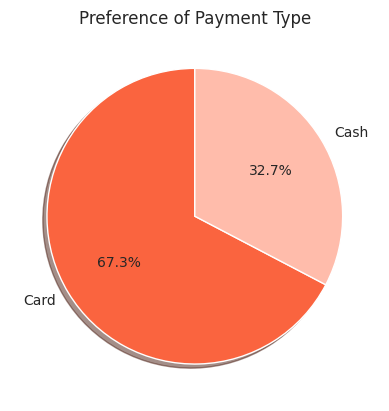

In [42]:
# Visualizing overall distribution of payment type

plt.title('Preference of Payment Type')
plt.pie(subset_df['payment_type'].value_counts(normalize = True), labels = subset_df['payment_type'].value_counts().index,
        startangle = 90, shadow = True, autopct = '%1.1F%%', colors = [prim, sec])

In [43]:
# Understanding of passenger count on payment type

passenger_count = subset_df.groupby(['payment_type', 'passenger_count'])[['passenger_count']].count()
passenger_count.rename(columns = {'passenger_count': 'count'}, inplace = True)
passenger_count.reset_index(inplace = True)
passenger_count

,payment_type,passenger_count,count
0,Card,1,909245
1,Card,2,327661
2,Card,3,122412
3,Card,4,63676
4,Card,5,124045
5,Cash,1,460550
6,Cash,2,155472
7,Cash,3,54506
8,Cash,4,32715
9,Cash,5,47626


In [44]:
passenger_count['perc'] = (passenger_count['count'] / passenger_count['count'].sum())* 100
passenger_count

,payment_type,passenger_count,count,perc
0,Card,1,909245,39.568381
1,Card,2,327661,14.259100
2,Card,3,122412,5.327106
3,Card,4,63676,2.771042
4,Card,5,124045,5.398171
5,Cash,1,460550,20.042143
6,Cash,2,155472,6.765806
7,Cash,3,54506,2.371984
8,Cash,4,32715,1.423686
9,Cash,5,47626,2.072581


In [45]:
# Creating a new transformed dataset to eventually create a stacked bar chart based on passenger count

unique_passenger_counts = [x for x in passenger_count['passenger_count'].unique()]
columns = ['payment_type'] + unique_passenger_counts

trans_passenger_count = pd.DataFrame(columns=columns)
trans_passenger_count['payment_type'] = passenger_count['payment_type'].unique()
trans_passenger_count.iloc[0, 1:] = passenger_count.iloc[:5, -1]
trans_passenger_count.iloc[1, 1:] = passenger_count.iloc[5:, -1]
trans_passenger_count

,payment_type,1,2,3,4,5
0,Card,39.568381,14.2591,5.327106,2.771042,5.398171
1,Cash,20.042143,6.765806,2.371984,1.423686,2.072581


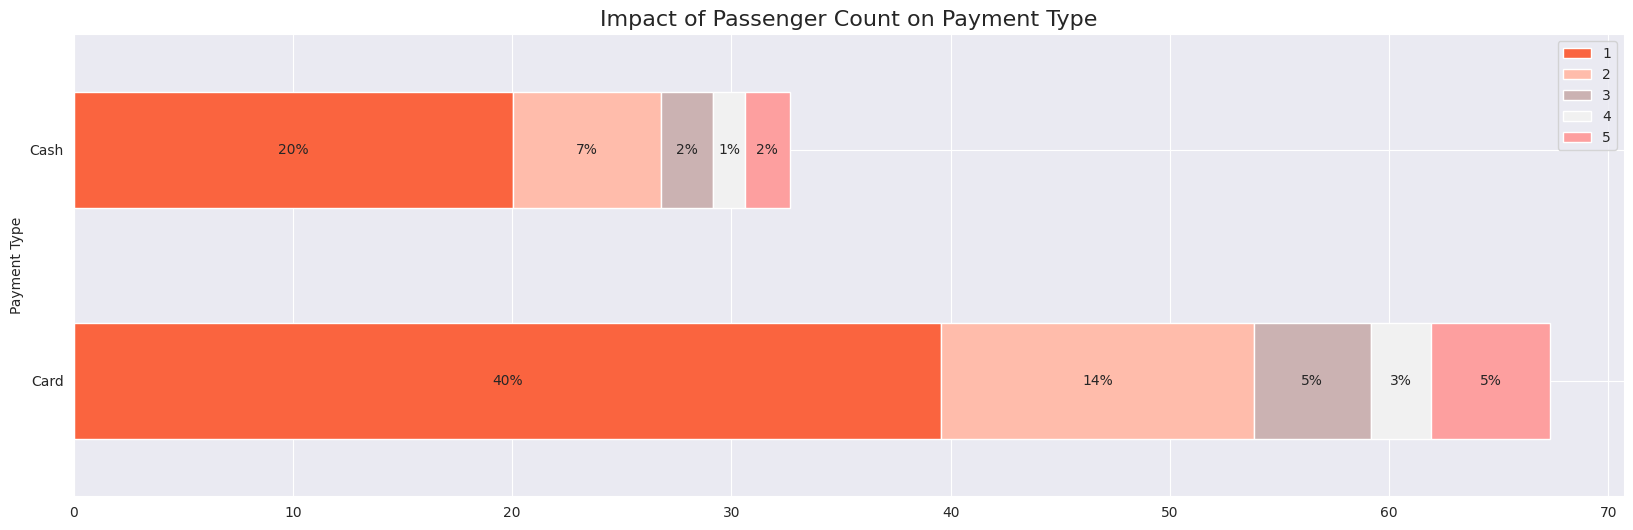

In [46]:
# Visualizing impact of passenger count on payment type
fig, ax = plt.subplots(figsize = (20, 6))
trans_passenger_count.plot(x ='payment_type', kind = 'barh', stacked = True, color = [prim, sec, ter, quar, quin],
                          ax = ax, ylabel = 'Payment Type')

# Adding a title
ax.set_title('Impact of Passenger Count on Payment Type', fontsize=16)

# Adding percent text
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    ax.text(x + width / 2, 
               y + height / 2,
               '{:.0f}%'.format(width),
               horizontalalignment = 'center', 
    verticalalignment = 'center')

## Hypothesis Testing

**Null Hypothesis :** There is no difference in average fare between customers who use credit cards and customers who use cash.

**Alternative Hypothesis :** There is a difference in average fare between customers who use credit cards and customers who use cash.

### Which Test to Use for Comparing `payment_type` (2 Groups) and `fare_amount` (Continuous):

- **Chi-square**: Cannot be used with continuous variables like `fare_amount`.
- **ANOVA**: Can be used if there are **2 or more groups**, but for exactly **2 groups**, a **t-test** is usually preferred.
- **Z Test**: Only if the sample size is large, the population standard deviation is known, and the distribution is normal.
- **T Test**: Typically used for comparing the means of **two independent groups** (e.g., `Card` vs `Cash`) when the sample size is small and the population standard deviation is unknown.

### Conclusion:
For comparing `payment_type` (with 2 independent groups) and `fare_amount` (continuous data), though the sample size is large, `fare_amount` does not follow normal distribution hence **use a T-test**.

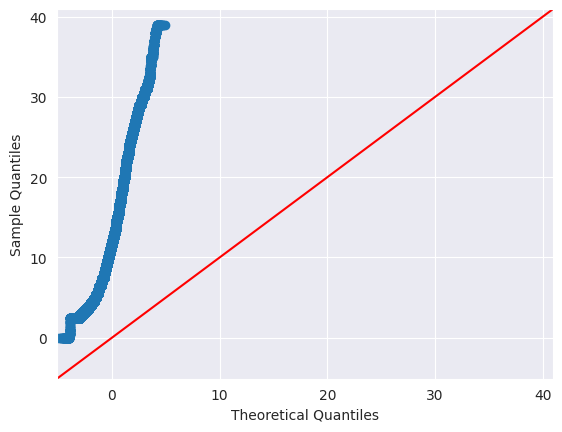

In [47]:
# Checking if Fare Amount is normall distrubited

sm.qqplot(subset_df['fare_amount'], line = '45')
plt.show()

# Since the points are not aligned with the line, we can deduce that fare_amount is not normally distributed

In [48]:
card_sample = subset_df[subset_df['payment_type'] == 'Card']['fare_amount']
cash_sample = subset_df[subset_df['payment_type'] == 'Cash']['fare_amount']

In [49]:
t_stats, p_value = stats.ttest_ind(a = card_sample, b = cash_sample, equal_var = False)
print('T statistics : ', t_stats, 'p-value : ', p_value)

T statistics :  169.2111527245052 p-value :  0.0


### What does this output signify?
**Result**: 

The t-statistic of 169.21 is extremely high, suggesting that the means of the two groups (e.g., card_sample and cash_sample) are very different.

A p-value of 0.0 means that the probability of observing such a large difference in sample means under the null hypothesis is extremely small (effectively zero).

### Conclusion:
Statistically significant result: Since the p-value is less than the commonly used significance level of 0.05 (and even far smaller), **we reject the null hypothesis** and **conclude that there is a significant difference between the two groups being compared (i.g., Payment Type - Card and Cash groups)**.

## Performing Linear Regression

Using Python's scikit-learn library for the regression analysis based on below columns -
1. `trip_duration_minutes` (numeric, independent variable X)
2. `fare_amount` (float, dependent variable Y)

In [50]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,duration
0,1.0,2020-01-01 00:28:15,2020-01-01 00:33:03,1.0,1.2,1.0,N,238,239,1.0,6.0,3.0,0.5,1.47,0.0,0.3,11.27,2.5,4.800000
1,1.0,2020-01-01 00:35:39,2020-01-01 00:43:04,1.0,1.2,1.0,N,239,238,1.0,7.0,3.0,0.5,1.50,0.0,0.3,12.30,2.5,7.416667
2,1.0,2020-01-01 00:47:41,2020-01-01 00:53:52,1.0,0.6,1.0,N,238,238,1.0,6.0,3.0,0.5,1.00,0.0,0.3,10.80,2.5,6.183333
3,1.0,2020-01-01 00:55:23,2020-01-01 01:00:14,1.0,0.8,1.0,N,238,151,1.0,5.5,0.5,0.5,1.36,0.0,0.3,8.16,0.0,4.850000
4,2.0,2020-01-01 00:01:58,2020-01-01 00:04:16,1.0,0.0,1.0,N,193,193,2.0,3.5,0.5,0.5,0.00,0.0,0.3,4.80,0.0,2.300000


In [51]:
# Define Features (X) and Target (Y)

X = df[['duration']]  # Independent variable (ensure it’s a 2D array)
y = df['fare_amount']  # Dependent variable

In [52]:
# Creating training and test sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [53]:
# Fit the Linear Regression Model

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [54]:
# Make predictions

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

In [55]:
# Evaluating the model

# Mean Squared Error
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
print(f"Train MSE: {train_mse}, Test MSE: {test_mse}")

#R squared error
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"Train R²: {train_r2}, Test R²: {test_r2}")

Train MSE: 144.77262390371948, Test MSE: 141.7824252410495
Train R²: 0.02023541110762761, Test R²: 0.017485593657060705


### What does this output signify?
1. **MSE results**
    - The Train and Test MSE values are relatively close, suggesting that the model has similar performance on both datasets and is not overfitting or underfitting.
    - However, the values themselves are quite high, implying that the model's predictions are not very close to the actual values.

2. **R squared results**
    - the 𝑅 squared values for both Train and Test datasets are extremely low (~2% and ~1.7%), suggesting that trip duration has minimal explanatory power for predicting fare amount in your data.

### Conclusion:
1. The very low 𝑅 squared values suggest that trip duration alone is not a strong predictor of fare amount.
2. The close Train and Test MSE values indicate that the model generalizes similarly on unseen data, even though the predictions are not highly accurate.
3. Need to incorporate additional features (e.g., trip distance, passenger count) to improve the model's predictive capability.

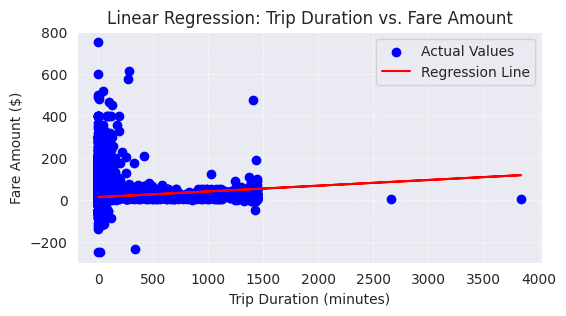

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 3))
plt.scatter(X_test, y_test, color='blue', label='Actual Values')
plt.plot(X_test, y_test_pred, color='red', label='Regression Line')
plt.title('Linear Regression: Trip Duration vs. Fare Amount')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount ($)')
plt.legend()
plt.grid(visible=True, linestyle='--', alpha=0.6)
plt.show()

# Summary of Findings and Recommendations

1. **Key Factors Influencing Revenue**:
   - Longer trips generally result in higher fares but might not always optimize revenue due to increased idle time.
   - Peak hours (e.g., late evenings) see higher demand, leading to increased revenue opportunities.
   - Linear regression analysis revealed that trip duration alone has minimal impact on fare prediction, as indicated by low R squared values (~2% for training data and ~1.7% for testing data). This suggests that other factors, such as trip distance or pickup time, may have stronger predictive power.

2. **Actionable Insights**:
   - Focus on shorter, frequent trips during peak hours for optimal earnings.
   - Explore popular routes and zones (e.g., airports or downtown areas) with high trip density.
   - Consider encouraging drivers to monitor trip characteristics (e.g., distance, time of day) beyond duration to maximize revenue.

3. **Future Improvements**:
   - Add features such as trip distance, passenger count, and time of day to improve the predictive power of the model.
   - Explore transformations or feature engineering to capture non-linear relationships in the data.
